# Neural Coding, Homework 4
Kai Rothe, Karim Zaghw

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Bernoulli Neuron: Fisher information and estimator ##

Assume a Bernoulli neuron with arbitrary tuning curve $f(s)$, i.e.
$$p(r| f(s)) = f(s)^r(1- f(s))^{1-r}, \qquad r \in \{0; 1\}$$

*Note: $r$ is discrete and $s$ is continuous.*

**(a)** Compute the Fisher information $J_s$. *(2 points)*

We use the result from the lecture on how $J_s$ depends on the Fisher information $J_f$ of the Bernoulli parameter $f$
\begin{split}
    J_s &= \left[\frac{\partial f(s)}{\partial s} \right]^2 \cdot J_f 
\end{split}
Where
\begin{split}
    J_f &:= Var\left(\frac{\partial}{\partial s} \log p\left(r | f(s)\right)\right) \\
    &= - E_r\left[\left(\frac{\partial^2}{\partial f^2} \log p(r | f) \right) | f \right] \text{ (c.f. lecture)} \\
    &= - E_r\left[\left(\frac{\partial^2}{\partial f^2} \log\left(f^r (1- f)^{1-r}\right) \right) | f \right] \\
    &= - E_r\left[\frac{\partial^2}{\partial f^2} \left(r \log f + (1-r) \log(1-f) \right) | f \right] \\
    &= - E_r\left[\frac{\partial}{\partial f} \left(\frac{r}{f} - \frac{1-r}{1-f} \right) | f \right] \\
    &= - E_r\left[- \frac{r}{f^2} - \frac{1-r}{(1-f)^2} | f \right] \\
    &= \frac{E_r\left[r | f \right]}{f^2} + \frac{1-E_r\left[r | f \right]}{(1-f)^2} \\
    &= \frac{1}{f} + \frac{1}{(1-f)} \text{ (since $E_r[r | f] = f$)} \\
    &= \frac{1}{f (1-f)}
\end{split}
Therefore 
\begin{split}
    J_s &= \frac{\left[\frac{\partial f(s)}{\partial s} \right]^2}{f(s) (1-f(s))} 
\end{split}

**(b)** Assume $f(s) = \frac{1}{1+s^2}$. Plot the Fisher information on the interval $s\in[-5, 5]$. Additionally, plot the Fisher information for a Poisson neuron with the same tuning curve using the formula from the lecture. *(2 points)*

If $f(s) = \frac{1}{1+s^2}$ then 
\begin{split}
    \left[\frac{\partial f(s)}{\partial s} \right]^2 = \left[- \frac{2s}{(1+s^2)^2} \right]^2 = \frac{4s^2}{(1+s^2)^4}
\end{split}
Thus for the Bernoulli neuron
\begin{split}
    J_s^B &= \frac{\frac{4s^2}{(1+s^2)^4}}{\frac{1}{1+s^2} (1-\frac{1}{1+s^2})} \\
    &= \frac{\frac{4s^2}{(1+s^2)^2}}{(1+s^2)-1} \\
    &= \frac{4}{(1+s^2)^2} \\
\end{split}
and for the Poisson neuron with $J_f^P = \frac{1}{f(s)} \text{ (c.f. lecture)} = 1+s^2$
\begin{split}
    J_s^P &= \frac{4s^2}{(1+s^2)^4} \cdot (1+s^2) = \frac{4s^2}{(1+s^2)^3} \\
\end{split}

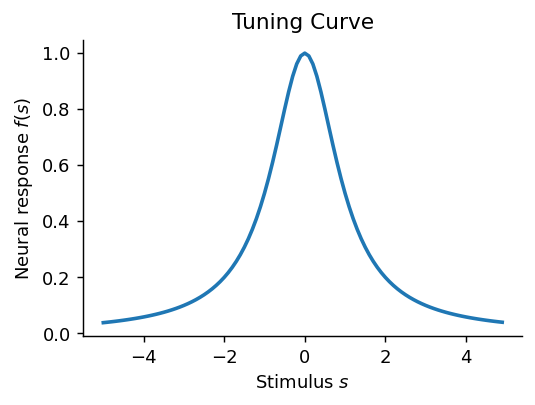

In [ ]:
def tuning_curve(s):
    return 1 / (1 + s**2)

s = np.arange(-5, 5, 0.1)

fig = plt.figure(dpi=130, figsize=(4, 3), constrained_layout = True)
plt.title("Tuning Curve")
plt.plot(s, tuning_curve(s), lw = 2)
plt.xlabel("Stimulus $s$")
plt.ylabel("Neural response $f(s)$")
sns.despine()

In [56]:
from scipy.special import factorial

def prob_r_bernoulli(r, s):
    return tuning_curve(s) * (r == 1) + (1 - tuning_curve(s)) * (r == 0)

def prob_r_poisson(r, s):
    return tuning_curve(s)**r / factorial(r, exact=True) * np.exp(-tuning_curve(s))

In [62]:
from ipywidgets import interact, FloatSlider

def plot_response_probability(s):
    fig = plt.figure(dpi=130, figsize=(4, 3), constrained_layout=True)
    plt.title("Response Probability")

    r_bernoulli = np.arange(0, 2, dtype=int)
    plt.bar(r_bernoulli, prob_r_bernoulli(r_bernoulli, s), label="Bernoulli", color="C0", width=0.5, alpha=0.8)

    r_poisson = np.arange(0, 6, dtype=int)
    plt.plot(r_poisson, prob_r_poisson(r_poisson, s), label="Poisson", color="C1", lw=2, marker="o", markersize=5)

    plt.xlabel("Response $r | s$ given Stimulus $s$")
    plt.ylabel("Probability $p(r | s)$")
    plt.ylim(0, 1.1)
    plt.legend(frameon=False, title="Neural Noise")
    snb.despine()
    # plt.show()

interact(plot_response_probability, s=FloatSlider(value=1., min=0., max=5., step=0.01, description='s'))
plt.show()

interactive(children=(FloatSlider(value=1.0, description='s', max=5.0, step=0.01), Output()), _dom_classes=('w…

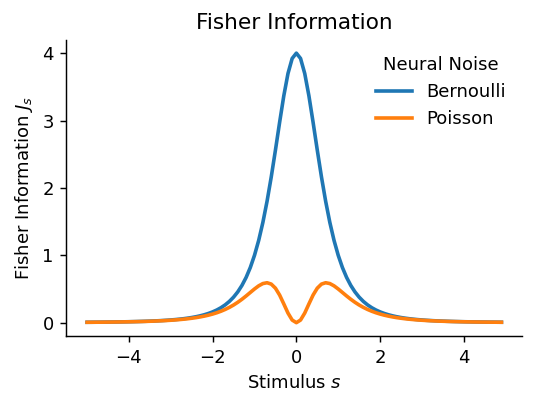

In [ ]:
def J_tc(s):
    return 4 * s**2 / (1 + s**2)**4

def J_f_bernoulli(s):
    return 1 / (tuning_curve(s) * (1 - tuning_curve(s)))

def J_f_poisson(s):
    return 1 / tuning_curve(s)

def J_bernoulli(s):
    return 4 / (1 + s**2)**2

def J_poisson(s):
    return 4 * s**2 / (1+s**2)**3

s = np.arange(-5, 5, 0.1)

fig = plt.figure(dpi=130, figsize=(4, 3), constrained_layout = True)
plt.title("Fisher Information")
# plt.plot(s, J_tc(s), label = "Tuning Curve Factor", lw = 2)
# plt.plot(s, J_f_bernoulli(s), label = "Bernoulli Factor", lw = 2)
# plt.plot(s, J_f_poisson(s), label = "Poisson Factor", lw = 2)
plt.plot(s, J_bernoulli(s), label = "Bernoulli", lw = 2)
plt.plot(s, J_poisson(s), label = "Poisson", lw = 2)
plt.xlabel("Stimulus $s$")
plt.ylabel("Fisher Information $J_s$")
plt.legend(frameon=False, title="Neural Noise")
sns.despine()

The Fisher information is symmetric since the Tuning curve is symmetric (only depends on $s^2$) and the distribution parameters, i.e. firing rates, always non-negative.

Intuitively, for Bernoulli neurons, the Fisher information peaks around $s=0$, since then the response becomes deterministic ($p(r=1|s=0) = 1$, i.e. $J_f^B$ has a maximim) and smaller values of $s$ allow clearer discrimination of $s$ given a response (tuning curve slope $|\frac{\partial f(s)}{\partial s}|$ maximal). 

For Poisson neurons, the Fisher information peaks between $s=1$, since for large $s$ the responses become deterministic ($p(r=0|s \rightarrow \infty) \rightarrow 1$, i.e. $J_f^P$ is maximal) but again smaller values of $s$ allow clearer discrimination of $s$ given a response (tuning curve slope $|\frac{\partial f(s)}{\partial s}|$ maximal). 

**(c)** Given an estimator
$\hat s(r) = \begin{cases} 1 & if\qquad r=0\\ 0 &if\qquad r=1\end{cases}$.\
Compute variance $\sigma^2(s)$, bias $b(s)$, and mean squared error $MS(s)$ of this estimator. Don't use the relationship $MS(s) = b^2(s) + \sigma^2(s)$, but instead compute them independently. *(2 points)*

*Confirm for yourself with an automatized tool like wolphramalpha that their relationship is correct.*

The definition implies 
\begin{split}
    \hat s(r) = 1 - r \sim f(s)^{1 - \hat s}(1- f(s))^{\hat s} = \text{Bernoulli}(\hat s | 1-f(s))
\end{split}
Then
\begin{split}
    \sigma_{\hat s}^2(s) &= f(s) (1-f(s)) \\
    &= \frac{1}{1 + s^2} (1 - \frac{1}{1 + s^2}) \\
    &= \frac{1}{1 + s^2} \frac{s^2}{1 + s^2} \\
    &= \left( \frac{s}{1 + s^2} \right)^2 \\
\end{split}
Furthermore
\begin{split}
    b(s) &= E_{\hat s}\left[\hat s | s \right] - s \\
    &= 1 - f(s) - s \\
    &= \frac{s^2}{1 + s^2} - s \\
    &= s \left(\frac{s}{1 + s^2} - 1\right) \\
\end{split}
And
\begin{split}
    MS(s) &= E_{\hat s}\left[(s - \hat s)^2 | s \right] \\
    &= \sum_{\hat s = 0}^1 (s - \hat s)^2 p(\hat s | s) \\
    &= \sum_{\hat s = 0}^1 (s - \hat s)^2 f(s)^{1 - \hat s}(1- f(s))^{\hat s} \\
    &= s^2 f(s) + (s - 1)^2 (1 - f(s)) \\
    &= \frac{s^2}{1 + s^2} + (1 - s)^2 \frac{s^2}{1 + s^2} \\
    &= \frac{s^2}{1 + s^2} \left[1 + (1 - s)^2\right] \\
\end{split}

Which was confirmed to satisfy the bias-variance trade-off relationship.

**(d)** Assume $s\sim\mathcal{U}([0,1])$. Compute the ideal observer $\hat s_{MS}(r)$. *(2 points)*

*Hint: Compute $p(r=0)$ and $p(r=1)$ with law of total probability. Then use Bayes' theorem to compute $p(s|r)$. Useful integrals:*
\begin{split}
\int \frac1{1+s^2} ds &= \tan^{-1}(s) + c, \qquad c\in\mathbb{R}\\
\int \frac{s}{1+s^2} ds &= \frac12 \ln(1+s^2) + c, \qquad c\in\mathbb{R} \\
\int \frac{s^2}{1+s^2} ds &= s - \tan^{-1}(s) + c, \qquad c\in\mathbb{R} \\
\int \frac{s^3}{1+s^2} ds &= \frac{s^2 - \ln(1+s^2)}{2} + c, \qquad c\in\mathbb{R}
\end{split}

From the lecture, we know that
\begin{split}
    \hat s_{MSE}(r) &:= \arg\min_{\hat s} MSE(\hat s | r) = \arg\min_{\hat s} E_s[(\hat s - s)^2 | r] = \arg\min_{\hat s} \int_{0}^{1} (\hat s - s)^2 \; p(s | r) \; ds
\end{split}
implies that 
\begin{split}
    \hat s_{MSE}(r) &= E_s[s | r] = \int_{0}^{1} s \; p(s | r) \; ds.
\end{split}
We use Bayes Theorem to compute
\begin{split}
    p(s | r) &= \frac{p(r | s) \cdot p(s)}{p(r)} \\
    &= \frac{p(r | f(s)) \cdot 1}{\int_0^1 p(r | f(s')) ds'} \\
    &= \frac{f(s)^r(1- f(s))^{1-r}}{\int_0^1 f(s')^r(1- f(s'))^{1-r} ds'} \\
    &= \frac{\left(\frac{1}{1+s^2}\right)^r \left(1- \frac{1}{1+s^2} \right)^{1-r}}{\int_0^1 \left(\frac{1}{1+s'^2}\right)^r \left(1- \frac{1}{1+s'^2} \right)^{1-r} ds'} \\
    &= \frac{\frac{1}{\left(1+s^2\right)^r} \frac{s^{2(1-r)}}{\left(1+s^2\right)^{1-r}}}{\int_0^1 \frac{1}{\left(1+s'^2\right)^r} \frac{s'^{2(1-r)}}{\left(1+s'^2\right)^{1-r}} ds'} \\
    &= \frac{\frac{s^{2-2r}}{1+s^2}}{\int_0^1 \frac{s'^{2-2r}}{1+s'^2} ds'} \\
\end{split}
where the prior $p(s) = 1 \; \forall s \in [0, 1]$ because $s\sim\mathcal{U}([0,1])$.

Then using the given integrals
\begin{split}
    p(s | r = 1) &= \frac{\frac{1}{1+s^2}}{\int_0^1 \frac{1}{1+s'^2} ds'} \\
    &= \frac{1}{(1+s^2) \cdot \tan^{-1}(s')|_{s'=0}^1} \\
    &= \frac{1}{(1+s^2) \left(\tan^{-1}(1) - \tan^{-1}(0)\right)} \\
    &= \frac{1}{(1+s^2) \left(\frac{\pi}{4} - 0\right)} \\
    & = \frac{4}{\pi (1 + s^2)}
\end{split}
and 
\begin{split}
    p(s | r = 0) &=  \frac{\frac{s^2}{1+s^2}}{\int_0^1 \frac{s'^2}{1+s'^2} ds'} \\
    &= \frac{\frac{s^2}{1+s^2}}{s' - \tan^{-1}(s')|_{s'=0}^1} \\
    &= \frac{\frac{s^2}{1+s^2}}{1 - \frac{\pi}{4} - (0 - 0)} \\
    &= \frac{\frac{s^2}{1+s^2}}{\frac{4 - \pi}{4}} \\
    &= \frac{4s^2}{(4 - \pi) (1+s^2)}
\end{split}

Therefore 
\begin{split}
    \hat s_{MSE}(r = 1) &= E_s[s | r = 1] = \int_{0}^{1} s \; p(s | r = 1) \; ds \\
    &= \int_{0}^{1} s \; \frac{4}{\pi (1 + s^2)} \; ds \\
    &= \frac{4}{\pi} \int_{0}^{1} \frac{s}{1+s^2} \; ds \\
    &= \frac{4}{\pi} \frac{1}{2} \ln(1+s^2)|_{s=0}^{1} \\
    &= \frac{2}{\pi} \left(\ln(2) - \ln(1)\right) \\
    &= \frac{2 \ln(2)}{\pi} \approx 0.44
\end{split}
and 
\begin{split}
    \hat s_{MSE}(r = 0) &= E_s[s | r = 0] = \int_{0}^{1} s \; p(s | r = 0) \; ds \\
    &= \int_{0}^{1} s \; \frac{4s^2}{(4-\pi) (1+s^2)} \; ds \\
    &= \frac{4}{(4-\pi)} \int_{0}^{1} \frac{s^3}{1+s^2} \; ds \\
    &= \frac{4}{(4-\pi)} \frac{s^2 - \ln(1+s^2)}{2}|_{s=0}^{1} \\
    &= \frac{4}{(4-\pi)} \left[(1 - \ln(2)) - (0 - \ln(1)) \right] \\
    &= \frac{2(1 - \ln(2))}{(4-\pi)} \approx 0.715
\end{split}

**(e)** Contextualize the previous exercises with Cramer-Rao bound. *(2 points)*

The Cramer-Rao bound is given by the Fisher information calculated in b) such that
\begin{split}
    Var\left[\hat s (r) | s \right] &\geq \frac{g'(s)^2}{J^B_s} = \frac{(-f'(s))^2}{\frac{4}{(1+s^2)^2}} = \frac{\frac{4s^2}{(1+s^2)^4}}{\frac{4}{(1+s^2)^2}} = \left(\frac{s}{1+s^2}\right)^2 
\end{split}

which is exactly the variance we calculated in part (c).

For part (d),

\begin{split}
g(s) = & \quad \mathbb{E}[\hat{s} | s] \\ 
& \quad \sum_{r=0}^1 \hat{s}(r) \cdot p(r | s) \\
& \quad \hat{s}(r=0) \cdot p(r=0 | s) + \hat{s}(r=1) \cdot p(r=1 | s) \\
& \quad \hat{s}(r=0) \cdot (1-f(s)) + \hat{s}(r=1) \cdot f(s)
\end{split}

therefore

\begin{split}
g'(s) = \hat{s}(0) \cdot (-f'(s)) + \hat{s}(1) \cdot f'(s) = f'(s) \cdot [\hat{s}(1) - \hat{s}(0)]
\end{split}

and the biased Cramer-Rao bound is

$$
\text{Var}(\hat{s} | s) \geq \frac{g'(s)^2}{J^B_s} = \frac{f'(s)^2 \cdot [\hat{s}(1) - \hat{s}(0)]^2}{\frac{(f'(s))^2}{f(s) [1 - f(s)]}} = [\hat{s}(1) - \hat{s}(0)]^2 f(s) [1 - f(s)]
$$

Now compute the variance explicitly:

\begin{split}
\text{Var}(\hat{s} | s) =& \mathbb{E}[\hat{s}^2 | s] - g(s)^2 \\
=&\; \hat{s}(0)^2 \cdot (1-f(s)) + \hat{s}(1)^2 \cdot f(s) - \Big[\hat{s}(0) \cdot (1-f(s)) + \hat{s}(1) \cdot f(s) \Big]^2 \\
=&\; \hat{s}(0)^2 \cdot (1-f(s)) + \hat{s}(1)^2 \cdot f(s) - \left[\hat{s}(0)^2 (1 - f(s))^2 + 2 \hat{s}(0)\hat{s}(1) f(s)(1 - f(s)) + \hat{s}(1)^2 f(s)^2 \right] \\
=&\; \hat{s}(0)^2 \left[(1-f(s)) - (1 - f(s))^2\right] + \hat{s}(1)^2 \left[f(s) - f(s)^2\right] - 2 \hat{s}(0)\hat{s}(1) f(s)(1 - f(s)) \\
=&\; (\hat{s}(0)^2 + \hat{s}(1)^2 - 2 \hat{s}(0)\hat{s}(1)) \cdot f(s)(1 - f(s)) \\
=&\; [\hat{s}(1) - \hat{s}(0)]^2 \cdot f(s)(1 - f(s))
\end{split}

Therefore, we find that

$$
\text{Var}(\hat{s} | s) = [\hat{s}(1) - \hat{s}(0)]^2 f(s)(1 - f(s)) \geq \frac{g'(s)^2}{J(s)} = [\hat{s}(1) - \hat{s}(0)]^2 f(s)(1 - f(s))
$$

and the bound is tight in this case as well.

## 2: Minimum Discrimination Error (MDE)

Given two stimuli $s_1$ and $s_2$ with probabilities $\lambda$ and $1-\lambda$, the response function is given as

$$p(r|s) = \begin{cases}
\tfrac12 &for & s=0 &and &r\in[-1,1]\\
\tfrac1{2x} &for &s=1 &and &r\in[-x, x]\\
0 &else
\end{cases}$$

**(a)** Draw diagrams for each possible case and highlight the MDE. Additionally, write down the decision for the Maximal a posteriori estimator $\hat{s}_{MAP}(r)$. *(2 points)*\
*Hint: Differentiate the cases by $\lambda$ and $x$. (there are 4 possibilities)*

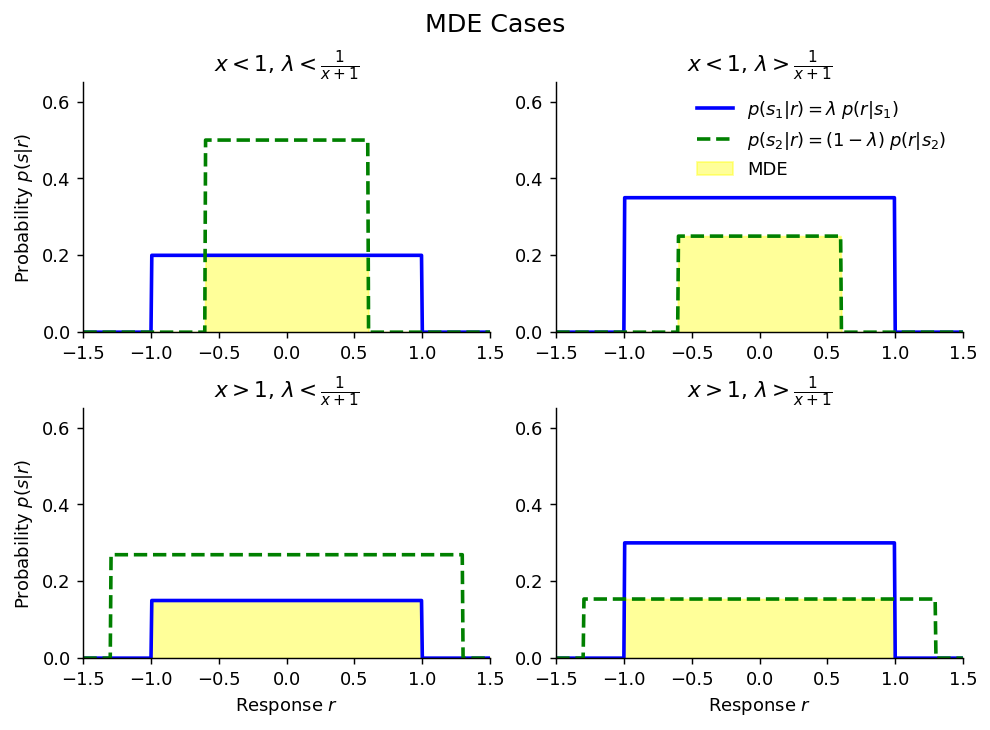

In [170]:
def plot_case(ax, x, lam, case_title):
    r = np.linspace(-1.5, 1.5, 500)
    # p(r|s1)
    p_s1 = np.where((r >= -1) & (r <= 1), 0.5, 0) * lam
    # p(r|s2)
    p_s2 = np.where((r >= -x) & (r <= x), 1/(2*x), 0) * (1-lam)

    ax.plot(r, p_s1, color='blue', lw=2, label='$p(s_1 | r) = \lambda \; p(r|s_1)$')
    ax.plot(r, p_s2, color='green', ls="--", lw=2, label='$p(s_2 | r) = (1-\lambda) \; p(r|s_2)$')
    ax.fill_between(r, np.minimum(p_s1, p_s2), color='yellow', alpha=0.4, label='MDE')

    ax.set_xlim(-1.5, + 1.5)
    ax.set_ylim(0, 0.65)
    ax.set_title(case_title)

fig, axs = plt.subplots(2, 2, figsize=(7.5, 5.5), dpi=130, constrained_layout=True)
# plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Case 1: x < 1, lambda < 1/(x+1)
plot_case(axs[0,0], x=0.6, lam=0.4, case_title=r'$x<1$, $\lambda < \frac{1}{x+1}$')
axs[0,0].set_ylabel('Probability $p(s|r)$')

# Case 2: x < 1, lambda > 1/(x+1)
plot_case(axs[0,1], x=0.6, lam=0.7, case_title=r'$x<1$, $\lambda > \frac{1}{x+1}$')
axs[0,1].legend(frameon=False)

# Case 3: x > 1, lambda < 1/(x+1)
plot_case(axs[1,0], x=1.3, lam=0.3, case_title=r'$x>1$, $\lambda < \frac{1}{x+1}$')
axs[1,0].set_ylabel('Probability $p(s|r)$')
axs[1,0].set_xlabel('Response $r$')

# Case 4: x > 1, lambda > 1/(x+1)
plot_case(axs[1,1], x=1.3, lam=0.6, case_title=r'$x>1$, $\lambda > \frac{1}{x+1}$')
axs[1,1].set_xlabel('Response $r$')

sns.despine()
plt.suptitle("MDE Cases", fontsize=14)
plt.show()

We use that the evidence is 1, i.e. 
\begin{split}
    p(s = s_1 = 0) &= \int_{-\infty}^{\infty} p(s = s_1 = 0 | r) dr \\
               &= \int_{-1}^{1} \frac{1}{2} dr = 1 \\ \\
    p(s = s_2 = 1) &= \int_{-\infty}^{\infty} p(s = s_2 = 1 | r) dr \\
               &= \int_{-x}^{x} \frac{1}{2x} dr \\ 
               &= \frac{1}{2x} \cdot 2x = 1 \\
\end{split}

We calculate the decision for $s_1$ in the range $r \in [-\min(1, x), \min(1, x)]$ by
\begin{split}
    \lambda \; p(r|s_1) &> (1-\lambda) \; p(r|s_2) \\
    \lambda \; \frac{1}{2} &> (1-\lambda) \; \frac{1}{2x} \\
    x &< \frac{1-\lambda}{\lambda} \\
    x &< \frac{1}{\lambda} - 1 \\
    \lambda &> \frac{1}{x + 1}
\end{split}

Then we obtain for all cases (only neglecting indifferent cases) the decision 
\begin{split}
    \hat{s}_{MAP}(r) &= \begin{cases}
            s_1 = 0 &\text{if } \lambda \; p(r|s_1) > (1-\lambda) \; p(r|s_2) \\
            s_2 = 1 &\text{else}
        \end{cases} \\
        &= \begin{cases}
            s_1 = 0 &\text{if } (x < 1 \text{ and } \lambda > \frac{1}{x+1})  \\
                    &\text{or } (x < |r| < 1 \text{ and } \lambda > \frac{1}{x+1}) \\
                    &\text{or } (x > 1 > |r| \text{ and } \lambda > \frac{1}{x+1}) \\
            s_2 = 1 &\text{if } (x > 1 \text{ and } \lambda < \frac{1}{x+1}) \\
                    &\text{or } (|r| < x < 1 \text{ and } \lambda > \frac{1}{x+1}) \\
                    &\text{or } (x > |r| > 1 \text{ and } \lambda > \frac{1}{x+1}) \\
        \end{cases} \\
\end{split}

**(b)** Compute the MDE for each case analytically. *(1 point)*

For $x < 1, \lambda < \frac{1}{x+1}$:
\begin{split}
    MDE &= \int_{-x}^x p(s_1 | r) dr = \int_{-x}^x \lambda \frac{1}{2} dr = x \lambda
\end{split}

For $x < 1, \lambda > \frac{1}{x+1}$:
\begin{split}
    MDE &= \int_{-x}^x p(s_2 | r) dr = \int_{-x}^x (1-\lambda) \frac{1}{2x} dr = 1-\lambda
\end{split}

For $x > 1, \lambda < \frac{1}{x+1}$:
\begin{split}
    MDE &= \int_{-1}^1 p(s_1 | r) dr = \int_{-1}^1 \lambda \frac{1}{2} dr = \lambda
\end{split}

For $x > 1, \lambda > \frac{1}{x+1}$:
\begin{split}
    MDE &= \int_{-1}^1 p(s_2 | r) dr = \int_{-1}^1 (1-\lambda) \frac{1}{2x} dr = \frac{1-\lambda}{x}
\end{split}

**(c)** Confirm your results by simulation for multiple sets of parameters $\lambda$ and $x$.
Choose your selection of parameters such that they cover all cases from (a). *(2 points)*
1. Generate stimuli (sufficient amount)
2. Generate responses
3. Apply estimator (write a function of $\hat{s}_{MAP}(r)$ from (a))
4. Compute MDE
5. Compare to analytical MDE

In [ ]:
def generate_stimuli(N, lam):
    # s1=0 with prob lam, s2=1 with prob 1-lam
    return np.random.choice([0, 1], size=N, p=[lam, 1-lam])

def generate_responses(stimuli, x):
    # For s=0: r ~ Uniform[-1, 1]
    # For s=1: r ~ Uniform[-x, x]
    r = np.empty_like(stimuli, dtype=float)
    mask0 = (stimuli == 0)
    mask1 = (stimuli == 1)
    r[mask0] = np.random.uniform(-1, 1, size=mask0.sum())
    r[mask1] = np.random.uniform(-x, x, size=mask1.sum())
    return r

def s_map_estimator(r, lam, x):
    # Decision rule from a)
    # For r in [-min(1, x), min(1, x)], compare lambda/2 vs (1-lambda)/(2x)
    # Otherwise, assign to the class whose support contains r
    s_hat = np.zeros_like(r)
    min1x = min(1, x)
    # In overlap region
    overlap = (r >= -min1x) & (r <= min1x)
    # Compute threshold
    if lam > 1/(x+1):
        s_hat[overlap] = 0
    else:
        s_hat[overlap] = 1
    # Outside overlap, assign by support
    s_hat[(r < -x) | (r > x)] = 0  # only s=0 possible
    s_hat[(r < -1) | (r > 1)] = 1  # only s=1 possible
    return s_hat

def analytical_mde(lam, x):
    if x < 1 and lam < 1/(x+1):
        return x * lam
    elif x < 1 and lam > 1/(x+1):
        return 1 - lam
    elif x > 1 and lam < 1/(x+1):
        return lam
    elif x > 1 and lam > 1/(x+1):
        return (1 - lam) / x
    else:
        return np.nan

# Parameters for all 4 cases
params = [
    # (x, lam, description)
    (0.6, 0.4, "Case 1: $x<1$, $λ<1/(x+1)$"),
    (0.6, 0.7, "Case 2: $x<1$, $λ>1/(x+1)$"),
    (1.3, 0.3, "Case 3: $x>1$, $λ<1/(x+1)$"),
    (1.3, 0.6, "Case 4: $x>1$, $λ>1/(x+1)$"),
]

N = 100000
np.random.seed(42)
for x, lam, desc in params:
    stimuli = generate_stimuli(N, lam)
    responses = generate_responses(stimuli, x)
    s_hat = s_map_estimator(responses, lam, x)
    mde_sim = np.mean(s_hat != stimuli)
    mde_analytical = analytical_mde(lam, x)
    print(f"{desc}: Simulated MDE = {mde_sim:.4f}, Analytical MDE = {mde_analytical:.4f}")

Case 1: $x<1$, $λ<1/(x+1)$: Simulated MDE = 0.2382, Analytical MDE = 0.2400
Case 2: $x<1$, $λ>1/(x+1)$: Simulated MDE = 0.2999, Analytical MDE = 0.3000
Case 3: $x>1$, $λ<1/(x+1)$: Simulated MDE = 0.2987, Analytical MDE = 0.3000
Case 4: $x>1$, $λ>1/(x+1)$: Simulated MDE = 0.3085, Analytical MDE = 0.3077


We validate the analytic solutions by observing closeby results of the simulation.